# Cosmic-ray transport equation solver
## **Reacceleration**

#### Imports

In [1]:
include("../Code/CRT_tools_3D.jl");
include("../Code/CRT_func_3D.jl");

#### Constants

In [2]:
const pc = 3e18;
const kpc = 1e3 * pc;

#### Grid definition

In [3]:
nr, nz, np = 10, 11, 1000;

r_min, r_max = pc, kpc;
z_min, z_max = pc, kpc;
p_min, p_max = 1.0, 1e6;

r_list, z_list, p_list, pu_list = make_grids(nr, nz, np, r_min, r_max, z_min, z_max, p_min, p_max);

#### Physical parameters

In [4]:
Dpp_0 = 5.1e-10
Q_0 = 1.0;
s = 4.0;
p_0 = 1e7; # p cut-off (10 TeV), MeV

#### Function for diffusion coefficient

In [5]:
Dp(r, z, p) = Dpp_0 * (p/p_0)^2;

#### Analytical solution for reacceleration

In [6]:
function N_reac(p::Float64)
    term_1 = ((p / p_0)^(-s-2) - (p_max / p_0)^(-s-2)) / (s + 2)
    term_2 = (p_min / p_0)^(1-s) * ((p_max / p_0)^-3 - (p / p_0)^-3) / 3
    dZ1 = 2.0 * z_list[length(z_list)÷2+2]
    dR1 = r_list[1]
    bin_factor = pi * dR1 * dR1 * dZ1
    return p^2 * (((Q_0 / bin_factor) / (Dpp_0 * (1-s))) * (term_1 + term_2))
end

N_sol_reac = zeros(np)

for k in eachindex(p_list)
    N_sol_reac[k] = N_reac(p_list[k])
end

#### Source term

In [7]:
function Q_reac(r::Float64, z::Float64, p::Float64, r_list::Vector{Float64}, z_list::Vector{Float64}, Q_0::Float64, p_0::Float64, s::Float64)
    if r==r_list[1] && (z==z_list[length(z_list)÷2+1] || z==z_list[length(z_list)÷2] || z==z_list[length(z_list)÷2+2]) 
        dZ1 = 2 * z_list[length(z_list)÷2+2]
        dR1 = r_list[1]
        bin_factor = pi * dR1 * dR1 * dZ1
        return (Q_0 / bin_factor) * (p / p_0)^-s
    else
        return 0
    end
end


Q_arr_reac = zeros(length(r_list), length(z_list), length(p_list)) # nr, nz, np

for k in eachindex(p_list)
    for j in eachindex(z_list)
        for i in eachindex(r_list)
            Q_arr_reac[i, j, k] = Q_reac(r_list[i], z_list[j], p_list[k], r_list, z_list, Q_0, p_0, s) # Q(r_i, z_j, p_k)
        end
    end
end

#### Time step definition

In [8]:
m=100;
Dt_list = make_dt_list(1e23, m);

Total physical time = 1.0998937565353474e30
No. of different Dts = 97


### **Transport equation solver**

In [9]:
prev_sol = zeros(nr, nz, np)

for it in eachindex(Dt_list)

    Dt = Dt_list[it]

    A_nextm, A_nm = make_Am(r_list, z_list, p_list, Dp, Dt)

    for n in 1:m

        global prev_sol

        B_nm = make_Bm(A_nm, prev_sol, Q_arr_reac, Dt)
        Threads.@threads for j in 1:nz
            @simd for i in 1:nr
                @inbounds prev_sol[i, j, :] = A_nextm[i, j] \ B_nm[i, j, :]
          end
        end 
    
    end

end

#### Plot using Julia

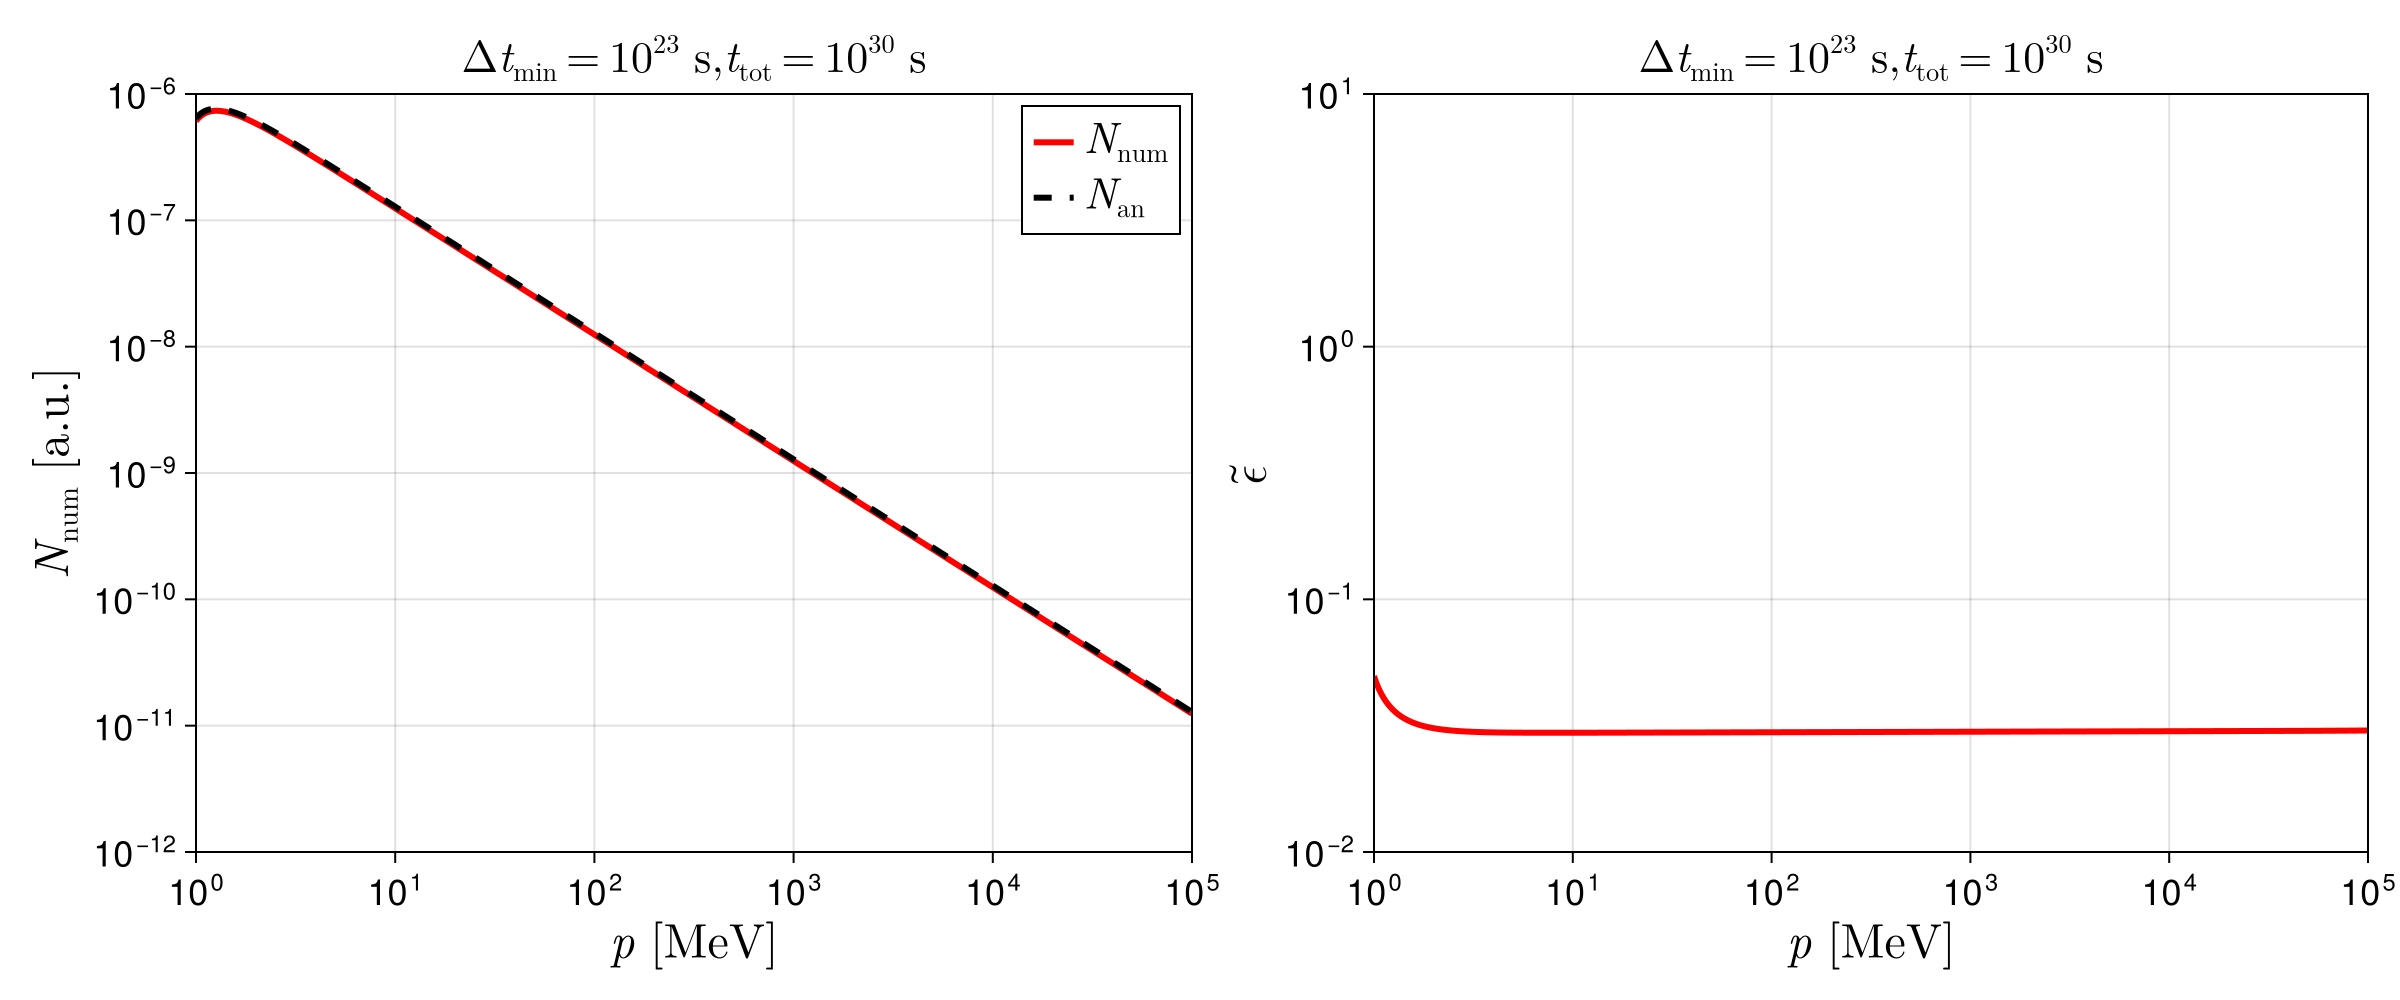

In [11]:
using CairoMakie

p = p_list

fig = Figure(size = (1200, 500), fontsize = 22)

# ---------------- LEFT: SOLUTION ----------------
ax1 = Axis(fig[1, 1],
    xlabel = L"p~[\mathrm{MeV}]",
    ylabel = L"N_{\mathrm{num}}~[\mathrm{a.u.}]",
    title = L"\Delta t_{\mathrm{min}}=10^{23}~\mathrm{s}, t_{\mathrm{tot}}=10^{30}~\mathrm{s}",
    xscale = log10,
    yscale = log10,
    limits = ((1.0, 1e5), (1e-12, 1e-6)),
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 22,
    xticklabelsize = 18,
    yticklabelsize = 18
)

lines!(ax1, p, prev_sol[1, 5, :], color = :red, linewidth = 3, label =  L"N_{\mathrm{num}}") # numerical (solid)
lines!(ax1, p, N_sol_reac, color = :black, linestyle = :dash, linewidth = 3, label = L"N_{\mathrm{an}}") # analytical (dashed)

axislegend(ax1, position = :rt, fontsize = 18)

# ---------------- RIGHT: ERROR ----------------
err = abs.(N_sol_reac .- prev_sol[1, 5, :]) ./ N_sol_reac

ax2 = Axis(fig[1, 2],
    xlabel = L"p~[\mathrm{MeV}]",
    ylabel = L"\tilde{\epsilon}",
    title = L"\Delta t_{\mathrm{min}}=10^{23}~\mathrm{s}, t_{\mathrm{tot}}=10^{30}~\mathrm{s}",
    xscale = log10,
    yscale = log10,
    limits = ((1.0, 1e5), (1e-2, 10)),
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 22,
    xticklabelsize = 18,
    yticklabelsize = 18
)

lines!(ax2, p, err, color = :red, linewidth = 3)

fig